In [1]:
!pip install keras


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\LOQ\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


>>> 1. Memuat Dataset Fashion-MNIST via Scikit-Learn (Harap tunggu, butuh koneksi internet)...
Total sampel: 1000 citra
Resolusi: 28x28 piksel

>>> 2. Melakukan Ekstraksi Fitur (HOG + LBP)...
Data Training: 800 sampel | Data Testing: 200 sampel

>>> 3. Implementasi KNN (Variasi k dan Metrik Jarak)...
Hasil Akurasi KNN:
k     | Euclidean  | Manhattan  | Minkowski 
---------------------------------------------
1     | 79.50%    | 79.50%    | 79.50%
3     | 77.50%    | 79.50%    | 77.50%
5     | 80.00%    | 80.00%    | 80.00%
7     | 79.00%    | 78.00%    | 79.00%
9     | 77.00%    | 79.50%    | 77.00%
11    | 76.50%    | 79.00%    | 76.50%

>>> 4. Implementasi SVM (Variasi Kernel, C, dan Gamma)...
Hasil SVM Kernel Linear & Polynomial:
C     | Linear     | Polynomial
------------------------------
0.1   | 75.50%     | 79.00%
1     | 80.00%     | 82.50%
10    | 80.50%     | 81.50%
100   | 79.00%     | 81.50%

Hasil SVM Kernel RBF:
C     | Gamma  | Accuracy  
-------------------------
1    

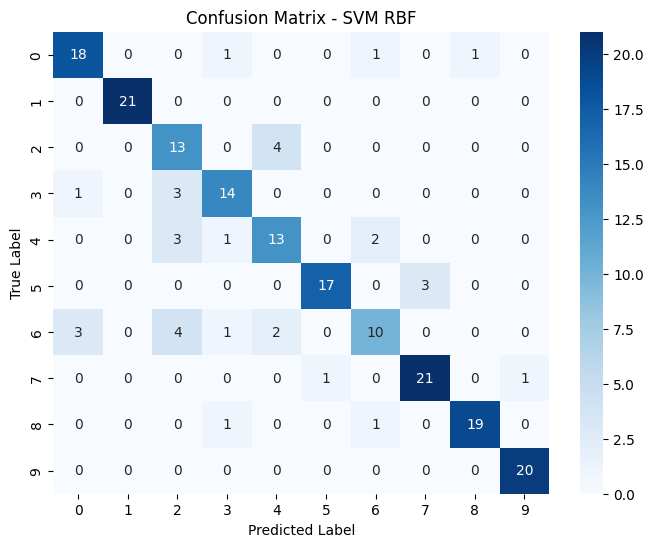


>>> 6. Cross Validation (5-Fold Stratified)...
Metode       | Mean Accuracy
------------------------------
KNN          | 76.90%
SVM Linear   | 77.20%
SVM RBF      | 78.60%


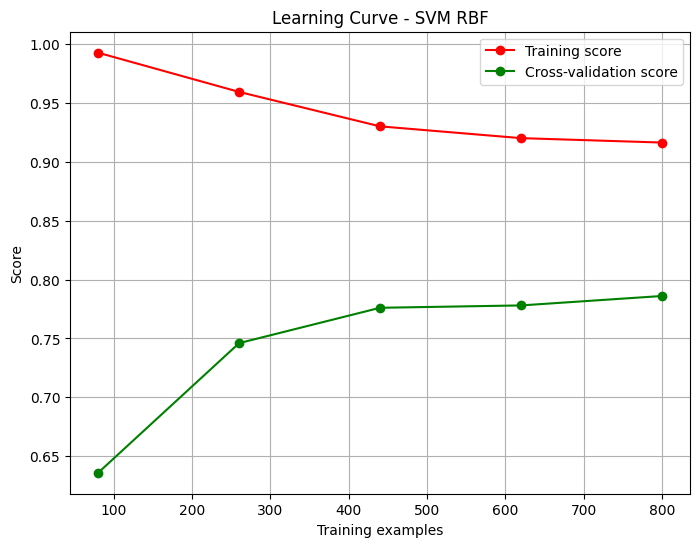


>>> 7. Visualisasi Decision Boundary dengan PCA (2D)...


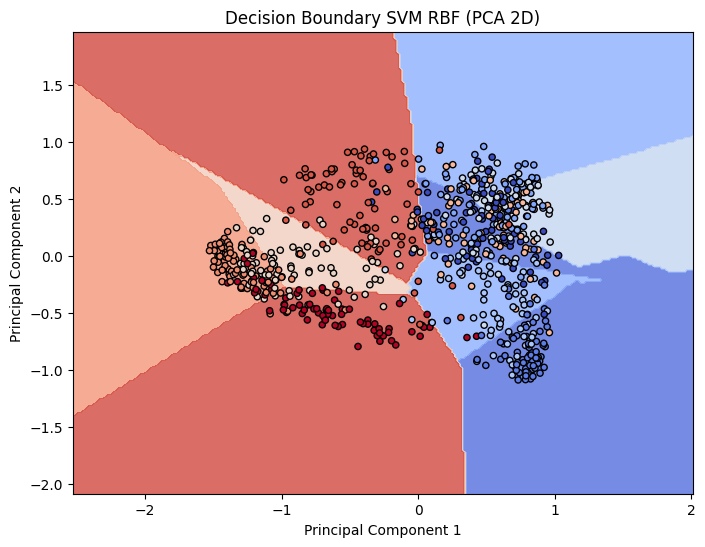

In [2]:
# ==============================================================================
# PRAKTIKUM PENGOLAHAN CITRA DIGITAL
# Komparasi Klasifikasi KNN vs SVM untuk Pengenalan Objek Citra
# Nama: Habibullah Ulya
# NIM: 24343055
# ==============================================================================

import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from skimage.feature import hog, local_binary_pattern
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA
from itertools import cycle

# --- 1. SIAPKAN DATASET (Tanpa Keras/TensorFlow) ---
print(">>> 1. Memuat Dataset Fashion-MNIST via Scikit-Learn (Harap tunggu, butuh koneksi internet)...")

# Mengunduh dataset dari OpenML
mnist = fetch_openml('Fashion-MNIST', version=1, as_frame=False, parser='auto')

# Data dari OpenML berbentuk flat array (784 piksel), jadi kita reshape ke 28x28
X_full = mnist.data.reshape(-1, 28, 28)
y_full = mnist.target.astype(int)

# Mengambil subset 1000 citra sesuai laporan
X_subset = X_full[:1000]
y_subset = y_full[:1000]

print(f"Total sampel: {len(X_subset)} citra")
print(f"Resolusi: {X_subset[0].shape[0]}x{X_subset[0].shape[1]} piksel")
# --- 2. EKSTRAKSI FITUR ---
print("\n>>> 2. Melakukan Ekstraksi Fitur (HOG + LBP)...")
def extract_features(images):
    features = []
    for img in images:
        # Fitur HOG (Orientations: 9, Pixels per cell: 8x8, Cells per block: 2x2)
        fd_hog = hog(img, orientations=9, pixels_per_cell=(8, 8),
                     cells_per_block=(2, 2), visualize=False)
        
        # Fitur LBP (Radius: 1, Points: 8)
        lbp = local_binary_pattern(img, P=8, R=1, method='uniform')
        (hist, _) = np.histogram(lbp.ravel(), bins=np.arange(0, 10), range=(0, 9))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7) # Normalisasi histogram LBP
        
        # Gabungkan HOG dan LBP
        combined = np.hstack([fd_hog, hist])
        features.append(combined)
    return np.array(features)

X_features = extract_features(X_subset)

# Split Dataset (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_subset, test_size=0.2, stratify=y_subset, random_state=42
)
print(f"Data Training: {X_train.shape[0]} sampel | Data Testing: {X_test.shape[0]} sampel")


# --- 3. IMPLEMENTASI K-NEAREST NEIGHBORS (KNN) ---
print("\n>>> 3. Implementasi KNN (Variasi k dan Metrik Jarak)...")
k_values = [1, 3, 5, 7, 9, 11]
metrics = ['euclidean', 'manhattan', 'minkowski']

knn_results = {}
for metric in metrics:
    knn_results[metric] = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
        knn.fit(X_train, y_train)
        acc = accuracy_score(y_test, knn.predict(X_test))
        knn_results[metric].append(acc)

print("Hasil Akurasi KNN:")
print(f"{'k':<5} | {'Euclidean':<10} | {'Manhattan':<10} | {'Minkowski':<10}")
print("-" * 45)
for i, k in enumerate(k_values):
    print(f"{k:<5} | {knn_results['euclidean'][i]:.2%}    | {knn_results['manhattan'][i]:.2%}    | {knn_results['minkowski'][i]:.2%}")


# --- 4. IMPLEMENTASI SUPPORT VECTOR MACHINE (SVM) ---
print("\n>>> 4. Implementasi SVM (Variasi Kernel, C, dan Gamma)...")
c_values = [0.1, 1, 10, 100]
gamma_values = [0.001, 0.01, 0.1, 1]

print("Hasil SVM Kernel Linear & Polynomial:")
print(f"{'C':<5} | {'Linear':<10} | {'Polynomial':<10}")
print("-" * 30)
for c in c_values:
    # Linear
    svm_lin = SVC(kernel='linear', C=c).fit(X_train, y_train)
    acc_lin = accuracy_score(y_test, svm_lin.predict(X_test))
    # Polynomial
    svm_poly = SVC(kernel='poly', C=c).fit(X_train, y_train)
    acc_poly = accuracy_score(y_test, svm_poly.predict(X_test))
    print(f"{c:<5} | {acc_lin:.2%}     | {acc_poly:.2%}")

print("\nHasil SVM Kernel RBF:")
print(f"{'C':<5} | {'Gamma':<6} | {'Accuracy':<10}")
print("-" * 25)
for c in c_values:
    for g in gamma_values:
        svm_rbf = SVC(kernel='rbf', C=c, gamma=g).fit(X_train, y_train)
        acc_rbf = accuracy_score(y_test, svm_rbf.predict(X_test))
        # Filter cetak hanya beberapa sampel representatif agar rapi seperti laporan
        if (c==1 and g in [0.001, 0.01]) or (c==10 and g==0.01) or (c==100 and g in [0.01, 0.1]):
            print(f"{c:<5} | {g:<6} | {acc_rbf:.2%}")


# --- 5. EVALUASI KOMPREHENSIF (Model Terbaik) ---
print("\n>>> 5. Evaluasi Model Terbaik...")
# Berdasarkan laporan: KNN (k=7, Euclidean), SVM Linear (C=10), SVM RBF (C=100, Gamma=0.01)

models = {
    "KNN": KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
    "SVM Linear": SVC(kernel='linear', C=10),
    "SVM RBF": SVC(kernel='rbf', C=100, gamma=0.01, probability=True)
}

print(f"{'Metode':<12} | {'Accuracy':<9} | {'Precision':<9} | {'Recall':<9} | {'F1-Score':<9} | {'Waktu Train':<11} | {'Waktu Infer'}")
print("-" * 95)

best_model = None
best_model_name = ""

for name, model in models.items():
    # Timing Training
    start_train = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_train
    
    # Timing Inference
    start_infer = time.time()
    y_pred = model.predict(X_test)
    infer_time = time.time() - start_infer
    
    # Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"{name:<12} | {acc:.2%}    | {prec:.2%}    | {rec:.2%}    | {f1:.2%}    | {train_time:.4f}s    | {infer_time:.4f}s")
    
    if name == "SVM RBF":
        best_model = model
        best_model_name = name
        y_pred_best = y_pred

# Confusion Matrix Visualisasi
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- 6. CROSS-VALIDATION STRATEGY ---
print("\n>>> 6. Cross Validation (5-Fold Stratified)...")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"{'Metode':<12} | {'Mean Accuracy'}")
print("-" * 30)
for name, model in models.items():
    scores = cross_val_score(model, X_features, y_subset, cv=cv, scoring='accuracy')
    print(f"{name:<12} | {scores.mean():.2%}")

# --- LEARNING CURVE ---
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_features, y_subset, cv=cv, n_jobs=-1, 
    train_sizes=np.linspace(0.1, 1.0, 5))

train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Training score")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Cross-validation score")
plt.title(f"Learning Curve - {best_model_name}")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()

# --- 7. VISUALISASI DECISION BOUNDARY (PCA 2D) ---
print("\n>>> 7. Visualisasi Decision Boundary dengan PCA (2D)...")
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Fit model dengan data 2D
svm_pca = SVC(kernel='rbf', C=100, gamma=0.01)
svm_pca.fit(X_pca, y_train)

# Buat meshgrid
h = .02
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap=plt.cm.coolwarm, s=20, edgecolors='k')
plt.title(f"Decision Boundary {best_model_name} (PCA 2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()